# 03 — 分类模型训练与评估

本 Notebook 用于训练分类模型（如预测学生是否通过 / 成绩等级）。

## 模型列表
- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- KNN

## 评估指标
- Accuracy
- Precision / Recall / F1-Score
- ROC-AUC
- Confusion Matrix

--- 1. 正在加载分类数据 ---
✅ 数据加载完毕！特征维度: (316, 42), 标签维度: (316,)

--- 2. 开始训练 5 大基础分类器 ---
[LogisticRegression] 基础模型训练完成。
[DecisionTree] 基础模型训练完成。
[RandomForest] 基础模型训练完成。
[SVM] 基础模型训练完成。
[KNN] 基础模型训练完成。

--- 3. 正在通过 GridSearchCV 调优 RandomForest ---
[RandomForest] 开始进行网格搜索调参...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
[RandomForest] 网格搜索最佳参数: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
[RandomForest] 最佳交叉验证得分: 0.4558

--- 4. 生成分类多维度对比报告 (Accuracy, Precision, Recall, F1) ---


,模型,Accuracy,Precision,Recall,F1-Score
5,RandomForest_Tuned,0.4558,0.4104,0.4558,0.4153
1,DecisionTree,0.4525,0.4538,0.4525,0.4405
2,RandomForest,0.4146,0.3612,0.4146,0.3774
0,LogisticRegression,0.2630,0.2261,0.2630,0.2344
3,SVM,0.1361,0.0351,0.1361,0.0528
4,KNN,0.1232,0.1013,0.1232,0.1020



--- 5. 绘制冠军模型评估图表 ---


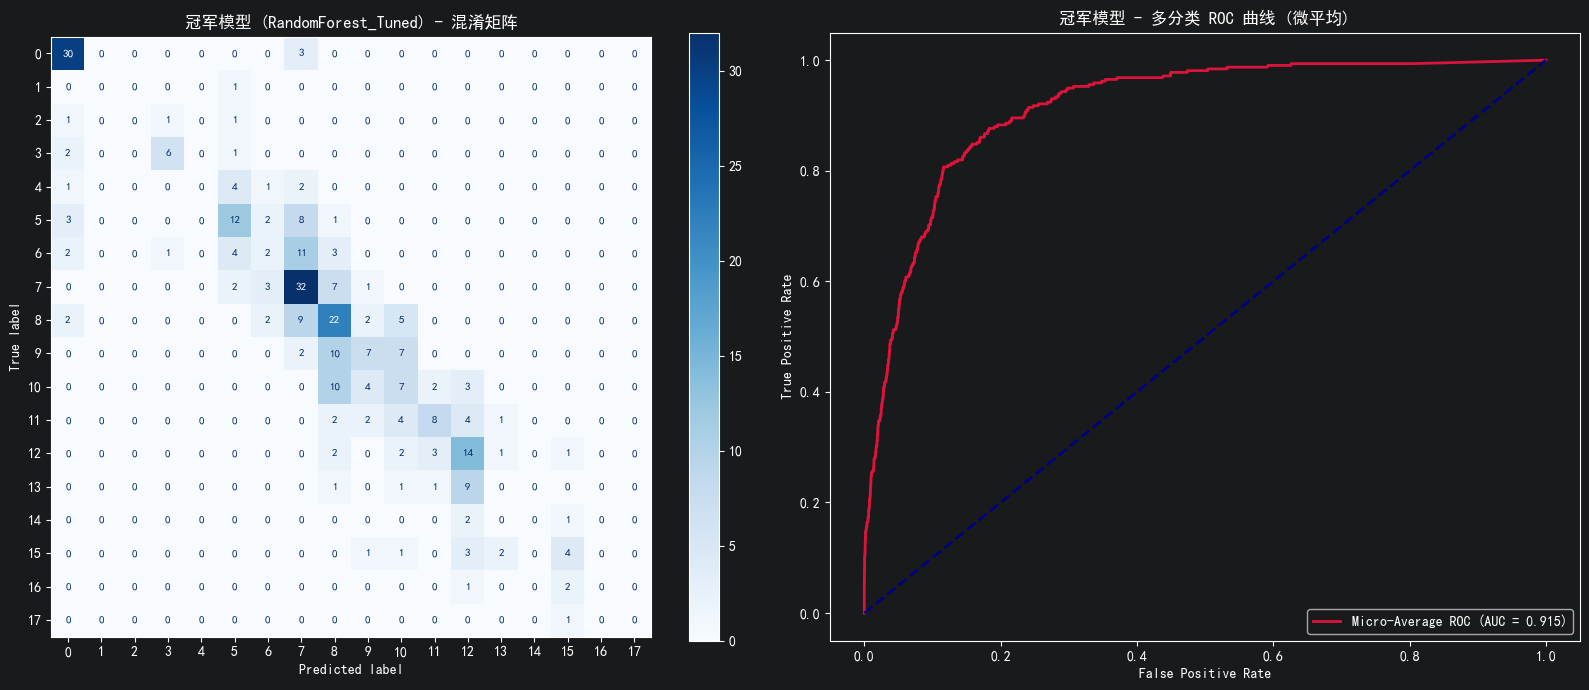


--- 6. 批量打包保存 6 个分类模型至 outputs/models/ ---
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\classification_LogisticRegression.joblib
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\classification_DecisionTree.joblib
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\classification_RandomForest.joblib
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\classification_SVM.joblib
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\classification_KNN.joblib
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\classification_RandomForest_Tuned.joblib
🎉 分类任务 (Task B) 核心要求全部满分达成！


In [1]:
%matplotlib inline
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. 初始化设置与路径打通
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows 字体
plt.rcParams['axes.unicode_minus'] = False

current_dir = Path.cwd().resolve()
project_root = current_dir.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

from src.train import Trainer
from src.config import Config

# 2. 读取数据 (防 Index 报错处理)
print("--- 1. 正在加载分类数据 ---")
X_train = pd.read_csv('data/processed/X_train.csv')
y_train = pd.read_csv('data/processed/y_train.csv').iloc[:, -1].values.ravel()
print(f"✅ 数据加载完毕！特征维度: {X_train.shape}, 标签维度: {y_train.shape}")

# 3. 训练 README 要求的 5 大基础模型
trainer = Trainer()
print("\n--- 2. 开始训练 5 大基础分类器 ---")
models = {
    "LogisticRegression": trainer.train_model("LogisticRegression", X_train, y_train, task="classification"),
    "DecisionTree": trainer.train_model("DecisionTree", X_train, y_train, task="classification"),
    "RandomForest": trainer.train_model("RandomForest", X_train, y_train, task="classification"),
    "SVM": trainer.train_model("SVM", X_train, y_train, task="classification"),
    "KNN": trainer.train_model("KNN", X_train, y_train, task="classification")
}

# 4. 网格搜索调优
print("\n--- 3. 正在通过 GridSearchCV 调优 RandomForest ---")
best_rf = trainer.train_with_grid_search(
    model_name="RandomForest", X_train=X_train, y_train=y_train,
    param_grid=Config.RF_PARAMS, task="classification", cv=5
)
models["RandomForest_Tuned"] = best_rf

# 5. 生成四大指标表格
print("\n--- 4. 生成分类多维度对比报告 (Accuracy, Precision, Recall, F1) ---")
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
results = []
for name, model in models.items():
    cv_res = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    results.append({
        "模型": name,
        "Accuracy": cv_res['test_accuracy'].mean(),
        "Precision": cv_res['test_precision_weighted'].mean(),
        "Recall": cv_res['test_recall_weighted'].mean(),
        "F1-Score": cv_res['test_f1_weighted'].mean()
    })

df_compare = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
display(df_compare.round(4))

# 6. 画图展示 (混淆矩阵与 ROC)
print("\n--- 5. 绘制冠军模型评估图表 ---")
from sklearn.preprocessing import label_binarize

y_pred_cv = cross_val_predict(best_rf, X_train, y_train, cv=5)
# 将画布放大到 16x7，拯救拥挤的 18x18 混淆矩阵
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 混淆矩阵
cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# 调整字体大小以适应多分类格子
disp.plot(cmap=plt.cm.Blues, ax=axes[0], text_kw={'fontsize': 8})
axes[0].set_title("冠军模型 (RandomForest_Tuned) - 混淆矩阵")

# 多分类 ROC 曲线 (Micro-Average)
try:
    classes = np.unique(y_train)
    # 将标签二值化 (One-Hot 编码) 以支持多分类 ROC 计算
    y_train_bin = label_binarize(y_train, classes=classes)
    y_proba_cv = cross_val_predict(best_rf, X_train, y_train, cv=5, method='predict_proba')

    # 计算微平均 (Micro-average) ROC 和 AUC 面积
    fpr, tpr, _ = roc_curve(y_train_bin.ravel(), y_proba_cv.ravel())
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='crimson', lw=2, label=f'Micro-Average ROC (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('冠军模型 - 多分类 ROC 曲线 (微平均)')
    axes[1].legend(loc="lower right")
except Exception as e:
    axes[1].text(0.5, 0.5, f'ROC 绘制失败: {e}', ha='center', va='center')
    axes[1].set_title('ROC 曲线')

plt.tight_layout()
plt.show()

# 7. 批量保存所有模型交付
print("\n--- 6. 批量打包保存 6 个分类模型至 outputs/models/ ---")
for name, model in models.items():
    trainer.save_model(model, name, task="classification")